In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import random

from matplotlib.patches import Patch

import cooler 
import cooltools
from matplotlib.colors import LogNorm
import cooltools.lib.plotting
from matplotlib.backends.backend_pdf import PdfPages

from functools import reduce 

import re
from collections import Counter

%cd /home/varshini/uc_analyses/
import utils, calc_insulation
%cd /home/varshini/LoopCall_Analysis_Scripts

import ast

# import libraries for biological data analysis
from coolpuppy import coolpup
from coolpuppy.lib import numutils
from coolpuppy.lib.puputils import divide_pups
from coolpuppy import plotpup
import cooler
import bioframe
import cooltools
from cooltools import expected_cis, expected_trans
from cooltools.lib import plotting

plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [2]:
savedir="/mnt/md0/varshini/Analysis/Blood/figs_v3/fig3"

if not os.path.exists(savedir):
    os.mkdir(savedir)

In [3]:
phases = ['Phase1_', 'Phase2_dedup',  'Phase3_dedup']
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/'

cooler_path = '/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran'

resolution=2000
phase_clr_names = [f'/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_{p}merged.250.mcool::resolutions/2000' for p in phases]

expdir = os.path.join('/mnt/md0/varshini/Analysis/Blood', 'microc_expected')
exps = [os.path.join(expdir, f"P_s_{phase}_2000bp_hg38arms.tsv") for phase in phases]

#[cooler.fileops.list_coolers(c) for c in phase_clr_names]
phase_clrs = [cooler.Cooler(c) for c in phase_clr_names]

dists = [25000, 50000, 100000, 200000]
phase_index=2
dist= dists[2]
phase=phases[phase_index]

type_use= 'erythroid_tf_acrs_all'
peak_use = 'enhancernotpromoternotctcf'

list_cols = ['crosser_loop_scores_P3', 'crosser_loop_classes_P3', 'crosser_loop_coords_P3',
            'ss_loop_scores_P3', 'ss_loop_classes_P3', 'ss_loop_coords_P3']

fname = 'erythroid_tf_acrs_all_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed'
test = pd.read_csv(os.path.join(datapath, fname), sep='\t')
#control = control.sample(len(test_unique), random_state=1)

test[list_cols] = test[list_cols].applymap(ast.literal_eval)


In [4]:
# loops

basedir = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/loops_anchors'

lc_fname_excl = 'merged_calls_125kb_q0.01_excl_classes_new.txt'
loop_classes_excl = pd.read_csv(os.path.join(basedir, lc_fname_excl), sep='\t').rename({'seqnames1':'chrom1','seqnames2':'chrom2'}, axis=1)
#loop_classes_excl[['start1','start2']] = loop_classes_excl[['start1','start2']] - 1
loop_classes_excl['coord1']=loop_classes_excl[['start1','end1']].mean(axis=1)
loop_classes_excl['coord2']=loop_classes_excl[['start2','end2']].mean(axis=1)

lc_fname = 'merged_calls_125kb_q0.01_classes_new.txt'
loop_classes = pd.read_csv(os.path.join(basedir, lc_fname), sep='\t').rename({'seqnames1':'chrom1','seqnames2':'chrom2','pair':'class'}, axis=1)
#loop_classes[['start1','start2']] = loop_classes[['start1','start2']] - 1
loop_classes['coord1']=loop_classes[['start1','end1']].mean(axis=1)
loop_classes['coord2']=loop_classes[['start2','end2']].mean(axis=1)

In [5]:
exploded = test.explode(['crosser_loop_scores_P3', 'crosser_loop_coords_P3', 'crosser_loop_classes_P3']).dropna(subset='crosser_loop_coords_P3')

exploded['start1'] = exploded['crosser_loop_coords_P3'].apply(lambda x: int(np.floor(x[0]-100)))
exploded['end1'] = exploded['crosser_loop_coords_P3'].apply(lambda x: int(np.floor(x[0]+100)))
exploded['start2'] = exploded['crosser_loop_coords_P3'].apply(lambda x: int(np.floor(x[1]-100)))
exploded['end2'] = exploded['crosser_loop_coords_P3'].apply(lambda x: int(np.floor(x[1]+100)))
exploded['chrom2'] = exploded['chr']
exploded['coord1'] = exploded['crosser_loop_coords_P3'].apply(lambda x: x[0])
exploded['coord2'] = exploded['crosser_loop_coords_P3'].apply(lambda x: x[1])
exploded['distance'] = exploded['coord2'] - exploded['coord1']
exploded.rename({'chr':'chrom1'}, inplace=True, axis=1)

exploded = test.explode(['ss_loop_scores_P3', 'ss_loop_coords_P3', 'ss_loop_classes_P3']).dropna(subset='ss_loop_coords_P3')

exploded['start1'] = exploded['ss_loop_coords_P3'].apply(lambda x: int(np.floor(x[0]-100)))
exploded['end1'] = exploded['ss_loop_coords_P3'].apply(lambda x: int(np.floor(x[0]+100)))
exploded['start2'] = exploded['ss_loop_coords_P3'].apply(lambda x: int(np.floor(x[1]-100)))
exploded['end2'] = exploded['ss_loop_coords_P3'].apply(lambda x: int(np.floor(x[1]+100)))
exploded['chrom2'] = exploded['chr']
exploded['coord1'] = exploded['ss_loop_coords_P3'].apply(lambda x: x[0])
exploded['coord2'] = exploded['ss_loop_coords_P3'].apply(lambda x: x[1])

exploded.rename({'chr':'chrom1'}, inplace=True, axis=1)

In [6]:
exploded.drop_duplicates(subset=['chrom1','start1','end1','chrom2','start2','end2'])

,chrom1,coord,perturbation_name,triangle_score_P1,crosser_loop_scores_P1,crosser_loop_classes_P1,crosser_loop_coords_P1,ss_loop_scores_P1,ss_loop_classes_P1,ss_loop_coords_P1,...,agg_ss_score_P3,quant,start1,end1,start2,end2,chrom2,coord1,coord2,distance
0,chr1,1024327.0,GATA1,1.139807,"[4.373343796104397, 2.691886454939779, 1.42679...","['P-CTCF', 'P-CTCF', 'P-Null']","[(984500.5, 1063500.5), (1017500.5, 1063500.5)...","[2.9640215758812216, 2.060386618930478]","['P-CTCF', 'P-Null']","[(1033500.5, 1063500.5), (1042500.5, 1058500.5)]",...,4.188574,2,984400,984600,1063400,1063600,chr1,984500.5,1063500.5,79000.0
0,chr1,1024327.0,GATA1,1.139807,"[4.373343796104397, 2.691886454939779, 1.42679...","['P-CTCF', 'P-CTCF', 'P-Null']","[(984500.5, 1063500.5), (1017500.5, 1063500.5)...","[2.9640215758812216, 2.060386618930478]","['P-CTCF', 'P-Null']","[(1033500.5, 1063500.5), (1042500.5, 1058500.5)]",...,4.188574,2,1017400,1017600,1063400,1063600,chr1,1017500.5,1063500.5,46000.0
0,chr1,1024327.0,GATA1,1.139807,"[4.373343796104397, 2.691886454939779, 1.42679...","['P-CTCF', 'P-CTCF', 'P-Null']","[(984500.5, 1063500.5), (1017500.5, 1063500.5)...","[2.9640215758812216, 2.060386618930478]","['P-CTCF', 'P-Null']","[(1033500.5, 1063500.5), (1042500.5, 1058500.5)]",...,4.188574,2,1020400,1020600,1040400,1040600,chr1,1020500.5,1040500.5,20000.0
3,chr1,2199415.5,GATA1,0.494884,[1.8190644657509427],['P-P'],"[(2196500.5, 2229500.5)]","[2.226825186060475, 3.5737908079348877]","['P-P', 'E-E']","[(2205500.5, 2227500.5), (2232500.5, 2290500.5)]",...,4.860562,0,2196400,2196600,2229400,2229600,chr1,2196500.5,2229500.5,33000.0
4,chr1,2278258.5,GFI1B,1.842449,"[4.291649408622616, 8.321646161565422, 3.80527...","['E-P', 'P-Null', 'E-P', 'E-P', 'E-P', 'E-E']","[(2196500.5, 2314500.5), (2196500.5, 2375500.5...","[1.8190644657509427, 2.226825186060475, None]","['P-P', 'P-P', 'E-E']","[(2196500.5, 2229500.5), (2205500.5, 2227500.5...",...,NaN,3,2196400,2196600,2314400,2314600,chr1,2196500.5,2314500.5,118000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3323,chrX,154799311.5,GATA1,1.310463,"[3.496344144563892, 4.423940644033462, 2.75962...","['E-CTCF', 'P-CTCF', 'P-P', 'P-P', 'P-CTCF']","[(154716500.5, 154840500.5), (154750500.5, 154...","[3.5956993954728635, None, 2.5321620777168756]","['E-P', 'P-P', 'P-P']","[(154716500.5, 154748500.5), (154751500.5, 154...",...,NaN,2,154716400,154716600,154840400,154840600,chrX,154716500.5,154840500.5,124000.0
3323,chrX,154799311.5,GATA1,1.310463,"[3.496344144563892, 4.423940644033462, 2.75962...","['E-CTCF', 'P-CTCF', 'P-P', 'P-P', 'P-CTCF']","[(154716500.5, 154840500.5), (154750500.5, 154...","[3.5956993954728635, None, 2.5321620777168756]","['E-P', 'P-P', 'P-P']","[(154716500.5, 154748500.5), (154751500.5, 154...",...,NaN,2,154750400,154750600,154840400,154840600,chrX,154750500.5,154840500.5,90000.0
3323,chrX,154799311.5,GATA1,1.310463,"[3.496344144563892, 4.423940644033462, 2.75962...","['E-CTCF', 'P-CTCF', 'P-P', 'P-P', 'P-CTCF']","[(154716500.5, 154840500.5), (154750500.5, 154...","[3.5956993954728635, None, 2.5321620777168756]","['E-P', 'P-P', 'P-P']","[(154716500.5, 154748500.5), (154751500.5, 154...",...,NaN,2,154751400,154751600,154802400,154802600,chrX,154751500.5,154802500.5,51000.0
3323,chrX,154799311.5,GATA1,1.310463,"[3.496344144563892, 4.423940644033462, 2.75962...","['E-CTCF', 'P-CTCF', 'P-P', 'P-P', 'P-CTCF']","[(154716500.5, 154840500.5), (154750500.5, 154...","[3.5956993954728635, None, 2.5321620777168756]","['E-P', 'P-P', 'P-P']","[(154716500.5, 154748500.5), (154751500.5, 154...",...,NaN,2,154763400,154763600,154804400,154804600,chrX,154763500.5,154804500.5,41000.0


In [7]:
exploded_merged = pd.merge(exploded,loop_classes,on=['chrom1','coord1','coord2'],
                           how="inner", suffixes=('','_lc'))

In [21]:
exploded_merged_mm = exploded_merged[(exploded_merged['quant']==2) | (exploded_merged['quant']==3)]
selected_loops = exploded_merged_mm.copy()
lc = ['CTCF-CTCF']
selected_loops = selected_loops[selected_loops['class'].isin(lc)]

In [22]:
exploded_merged_mm.drop_duplicates(subset=['chrom1','start1','end1','chrom2','start2','end2']).groupby('class').agg('size')

class
CTCF-CTCF    295
CTCF-Null    151
E-CTCF       299
E-E          380
E-Null       135
E-P          873
Null-Null     65
P-CTCF       438
P-Null       159
P-P          677
dtype: int64

<AxesSubplot:xlabel='distance', ylabel='Count'>

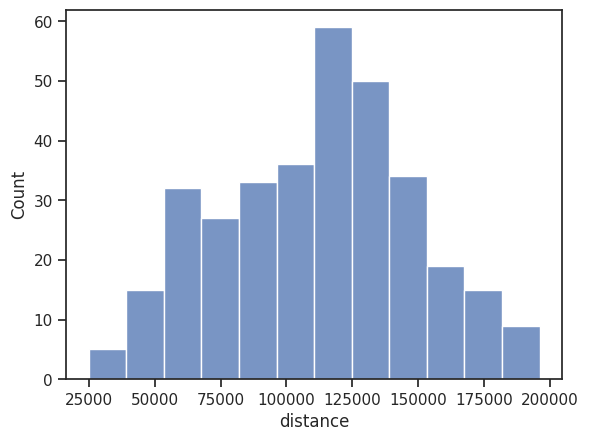

In [23]:
counts, bin_edges = np.histogram(selected_loops['distance'], bins=20)
sns.histplot(selected_loops['distance'])

In [24]:
sites

,chrom1,start1,end1,chrom2,start2,end2
17643,chr1,52700501.0,52705500.0,chr1,52722501.0,52727500.0
11117,chr11,119354001.0,119359000.0,chr11,119371001.0,119376000.0
24138,chr11,57432501.0,57437500.0,chr11,57452501.0,57457500.0
11126,chr11,122756001.0,122761000.0,chr11,122777001.0,122782000.0
2696,chr2,169108001.0,169113000.0,chr2,169139001.0,169144000.0
...,...,...,...,...,...,...
20057,chr4,46930501.0,46935500.0,chr4,47120501.0,47125500.0
12914,chr14,96098001.0,96103000.0,chr14,96294001.0,96299000.0
1672,chr1,234112001.0,234117000.0,chr1,234308001.0,234313000.0
11884,chr12,108610001.0,108615000.0,chr12,108801001.0,108806000.0


INFO:coolpuppy:('chr1_p', 'chr1_p'): 16
INFO:coolpuppy:('chr1_q', 'chr1_q'): 23
INFO:coolpuppy:('chr2_p', 'chr2_p'): 2
INFO:coolpuppy:('chr2_q', 'chr2_q'): 13
INFO:coolpuppy:('chr3_p', 'chr3_p'): 6
INFO:coolpuppy:('chr3_q', 'chr3_q'): 1
INFO:coolpuppy:('chr4_p', 'chr4_p'): 5
INFO:coolpuppy:('chr4_q', 'chr4_q'): 3
INFO:coolpuppy:('chr5_p', 'chr5_p'): 2
INFO:coolpuppy:('chr5_q', 'chr5_q'): 16
INFO:coolpuppy:('chr6_p', 'chr6_p'): 6
INFO:coolpuppy:('chr6_q', 'chr6_q'): 5
INFO:coolpuppy:('chr7_p', 'chr7_p'): 5
INFO:coolpuppy:('chr7_q', 'chr7_q'): 5
INFO:coolpuppy:('chr8_p', 'chr8_p'): 4
INFO:coolpuppy:('chr8_q', 'chr8_q'): 8
INFO:coolpuppy:('chr9_q', 'chr9_q'): 14
INFO:coolpuppy:('chr10_p', 'chr10_p'): 1
INFO:coolpuppy:('chr10_q', 'chr10_q'): 14
INFO:coolpuppy:('chr11_p', 'chr11_p'): 6
INFO:coolpuppy:('chr11_q', 'chr11_q'): 13
INFO:coolpuppy:('chr12_p', 'chr12_p'): 6
INFO:coolpuppy:('chr12_q', 'chr12_q'): 13
INFO:coolpuppy:('chr13_q', 'chr13_q'): 4
INFO:coolpuppy:('chr14_q', 'chr14_q'): 8
I

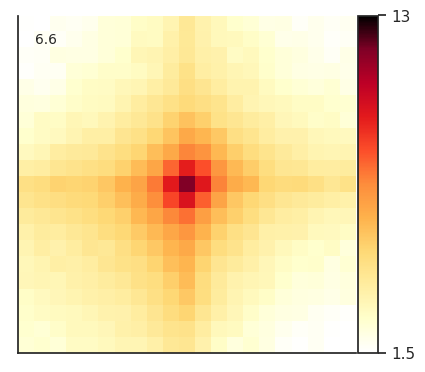

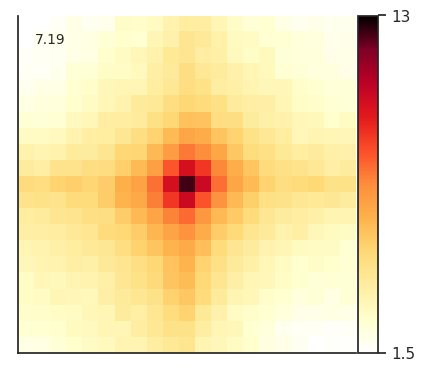

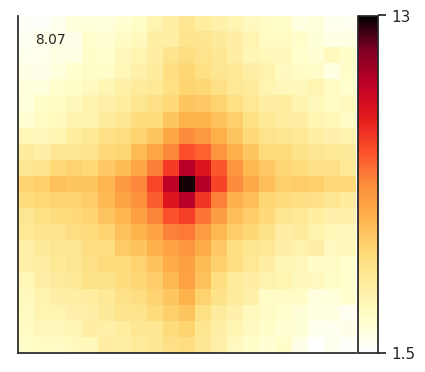

In [25]:
sites = selected_loops[['chrom1','start1','end1','chrom2','start2','end2']].drop_duplicates()
for i, (clr, expfile) in enumerate(zip(phase_clrs, exps)):
    vf = utils.get_hg38_arms(clr, excl_ym=True)
    exp = pd.read_csv(expfile, sep='\t')

    pup = coolpup.pileup(clr, sites, features_format='bedpe', view_df=vf, local=False,
                     expected_df=exp, flank=20_000, min_diag=0)
    fg = plotpup.plot(pup,
                     score=True, cmap='fall', scale='log', sym=False,height=5, vmax=13, vmin=1.5)
    #fg.savefig(os.path.join(savedir, f"CTCF-CTCF_phase{i+1}_MM.svg"))
    fg

In [26]:
selected_loops=pd.merge(loop_classes_excl,exploded[(exploded['quant']==2) | (exploded['quant']==3)],on=['chrom1','coord1','coord2'],
                        how="outer",indicator=True, suffixes=('', '_explode'))
selected_loops=selected_loops[selected_loops['_merge']=='left_only']

selected_loops = selected_loops[selected_loops['class'].isin(lc)]
selected_loops['distance'] = selected_loops['coord2']-selected_loops['coord1']

In [27]:
bin_edges[1]

33550.0

In [28]:
loops_dist = pd.DataFrame(columns = selected_loops.columns)

count_freq = (int(np.round(c)) for c in counts/sum(counts)*1000)
for i, count in enumerate(count_freq):
    print(i, count)
    loops_sub = selected_loops[(selected_loops['distance'] > bin_edges[i]) &
                                       (selected_loops['distance'] < bin_edges[i+1])].sample(count, random_state=24)
    loops_dist = pd.concat([loops_dist, loops_sub], axis=0)
    

sites = loops_dist[['chrom1','start1','end1','chrom2','start2','end2']]


0 9
1 6
2 39
3 39
4 63
5 57
6 42
7 63
8 48
9 78
10 120
11 87
12 93
13 66
14 63
15 36
16 36
17 30
18 21
19 6


(array([ 15.,  78., 120., 105., 126., 207., 159.,  99.,  66.,  27.]),
 array([ 26000.,  42900.,  59800.,  76700.,  93600., 110500., 127400.,
        144300., 161200., 178100., 195000.]),
 <BarContainer object of 10 artists>)

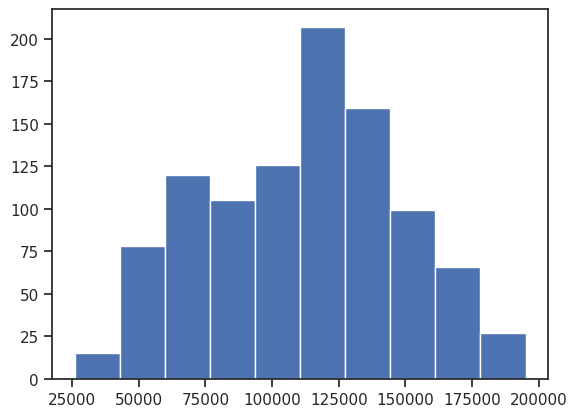

In [29]:
plt.hist(loops_dist['distance'])

/mnt/md0/varshini/Analysis/Blood/microc_expected/P_s_Phase1__2000bp_hg38arms.tsv


INFO:coolpuppy:('chr4_p', 'chr4_p'): 13
INFO:coolpuppy:('chr5_p', 'chr5_p'): 10
INFO:coolpuppy:('chr6_p', 'chr6_p'): 21
INFO:coolpuppy:('chr7_p', 'chr7_p'): 14
INFO:coolpuppy:('chr2_p', 'chr2_p'): 28
INFO:coolpuppy:('chr1_q', 'chr1_q'): 58
INFO:coolpuppy:('chr3_p', 'chr3_p'): 11
INFO:coolpuppy:('chr8_p', 'chr8_p'): 19
INFO:coolpuppy:('chr3_q', 'chr3_q'): 33
INFO:coolpuppy:('chr1_p', 'chr1_p'): 61
INFO:coolpuppy:('chr9_p', 'chr9_p'): 11
INFO:coolpuppy:('chr10_p', 'chr10_p'): 11
INFO:coolpuppy:('chr7_q', 'chr7_q'): 34
INFO:coolpuppy:('chr6_q', 'chr6_q'): 26
INFO:coolpuppy:('chr4_q', 'chr4_q'): 25
INFO:coolpuppy:('chr2_q', 'chr2_q'): 52
INFO:coolpuppy:('chr5_q', 'chr5_q'): 35
INFO:coolpuppy:('chr8_q', 'chr8_q'): 31
INFO:coolpuppy:('chr12_p', 'chr12_p'): 15
INFO:coolpuppy:('chr11_p', 'chr11_p'): 20
INFO:coolpuppy:('chr9_q', 'chr9_q'): 27
INFO:coolpuppy:('chr16_p', 'chr16_p'): 14
INFO:coolpuppy:('chr17_p', 'chr17_p'): 11
INFO:coolpuppy:('chr18_p', 'chr18_p'): 1
INFO:coolpuppy:('chr10_q', 'c

/mnt/md0/varshini/Analysis/Blood/microc_expected/P_s_Phase2_dedup_2000bp_hg38arms.tsv


INFO:coolpuppy:('chr1_q', 'chr1_q'): 58
INFO:coolpuppy:('chr5_p', 'chr5_p'): 10
INFO:coolpuppy:('chr4_p', 'chr4_p'): 13
INFO:coolpuppy:('chr6_q', 'chr6_q'): 26
INFO:coolpuppy:('chr6_p', 'chr6_p'): 21
INFO:coolpuppy:('chr7_p', 'chr7_p'): 14
INFO:coolpuppy:('chr3_p', 'chr3_p'): 11
INFO:coolpuppy:('chr2_p', 'chr2_p'): 28
INFO:coolpuppy:('chr8_p', 'chr8_p'): 19
INFO:coolpuppy:('chr9_p', 'chr9_p'): 11
INFO:coolpuppy:('chr3_q', 'chr3_q'): 33
INFO:coolpuppy:('chr1_p', 'chr1_p'): 61
INFO:coolpuppy:('chr5_q', 'chr5_q'): 35
INFO:coolpuppy:('chr9_q', 'chr9_q'): 27
INFO:coolpuppy:('chr11_p', 'chr11_p'): 20
INFO:coolpuppy:('chr10_p', 'chr10_p'): 11
INFO:coolpuppy:('chr7_q', 'chr7_q'): 34
INFO:coolpuppy:('chr12_p', 'chr12_p'): 15
INFO:coolpuppy:('chr4_q', 'chr4_q'): 25
INFO:coolpuppy:('chr16_p', 'chr16_p'): 14
INFO:coolpuppy:('chr17_p', 'chr17_p'): 11
INFO:coolpuppy:('chr8_q', 'chr8_q'): 31
INFO:coolpuppy:('chr18_p', 'chr18_p'): 1
INFO:coolpuppy:('chr11_q', 'chr11_q'): 33
INFO:coolpuppy:('chr16_q', 

/mnt/md0/varshini/Analysis/Blood/microc_expected/P_s_Phase3_dedup_2000bp_hg38arms.tsv


INFO:coolpuppy:('chr4_p', 'chr4_p'): 13
INFO:coolpuppy:('chr6_p', 'chr6_p'): 21
INFO:coolpuppy:('chr5_p', 'chr5_p'): 10
INFO:coolpuppy:('chr7_p', 'chr7_p'): 14
INFO:coolpuppy:('chr6_q', 'chr6_q'): 26
INFO:coolpuppy:('chr8_p', 'chr8_p'): 19
INFO:coolpuppy:('chr4_q', 'chr4_q'): 25
INFO:coolpuppy:('chr1_q', 'chr1_q'): 58
INFO:coolpuppy:('chr9_p', 'chr9_p'): 11
INFO:coolpuppy:('chr2_p', 'chr2_p'): 28
INFO:coolpuppy:('chr7_q', 'chr7_q'): 34
INFO:coolpuppy:('chr10_p', 'chr10_p'): 11
INFO:coolpuppy:('chr9_q', 'chr9_q'): 27
INFO:coolpuppy:('chr11_p', 'chr11_p'): 20
INFO:coolpuppy:('chr12_p', 'chr12_p'): 15
INFO:coolpuppy:('chr5_q', 'chr5_q'): 35
INFO:coolpuppy:('chr16_p', 'chr16_p'): 14
INFO:coolpuppy:('chr10_q', 'chr10_q'): 60
INFO:coolpuppy:('chr17_p', 'chr17_p'): 11
INFO:coolpuppy:('chr12_q', 'chr12_q'): 37
INFO:coolpuppy:('chr16_q', 'chr16_q'): 15
INFO:coolpuppy:('chr1_p', 'chr1_p'): 61
INFO:coolpuppy:('chr18_p', 'chr18_p'): 1
INFO:coolpuppy:('chr15_q', 'chr15_q'): 32
INFO:coolpuppy:('chr1

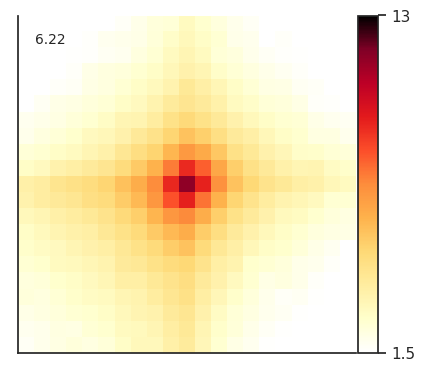

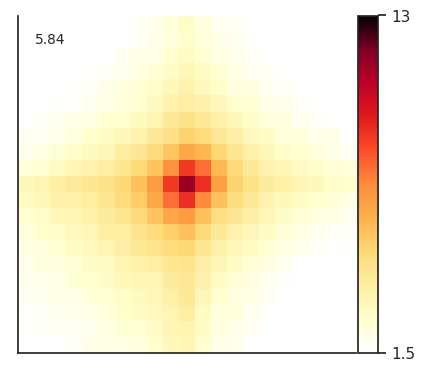

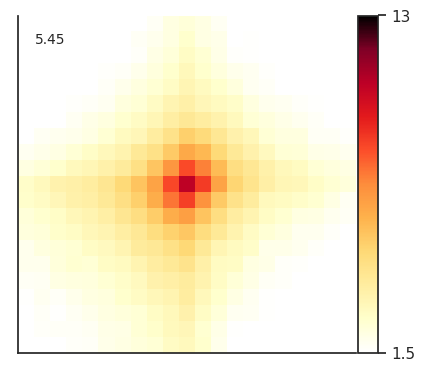

In [30]:
for i, (clr, expfile) in enumerate(zip(phase_clrs, exps)):
    vf = utils.get_hg38_arms(clr, excl_ym=True)
    print(expfile)
    exp = pd.read_csv(expfile, sep='\t')

    pup = coolpup.pileup(clr, sites, features_format='bedpe', view_df=vf, local=False,
                     expected_df=exp, flank=20_000, min_diag=0, nproc=12, )
    fg = plotpup.plot(pup,
                     score=True, cmap='fall', scale='log', sym=False,height=5, vmax=13, vmin=1.5)
    fg
    #fg.savefig(os.path.join(savedir, f"CTCF-CTCF_phase{i+1}_notMM.svg"))

exploded_merged = pd.merge(exploded,loop_classes,on=['chrom1','coord1','coord2'],
                           how="inner", suffixes=('','_lc'))
for quant in [3, 2]:
    selected_loops = exploded_merged[exploded_merged["quant"]==quant]
    lc = ['CTCF-CTCF', 'E-CTCF', 'P-CTCF']
    selected_loops = selected_loops[(selected_loops['pair']=='CTCF-CTCF') |
                               (selected_loops['pair']=='P-CTCF') |
                                (selected_loops['pair']=='E-CTCF')]
    sites = selected_loops[['chrom1','start1','end1','chrom2','start2','end2']].drop_duplicates()
    print(sites)
    for i, (clr, expfile) in enumerate(zip(phase_clrs, exps)):
        vf = utils.get_hg38_arms(clr, excl_ym=True)
        print(expfile)
        exp = pd.read_csv(expfile, sep='\t')

        pup = coolpup.pileup(clr, sites, features_format='bedpe', view_df=vf, local=False,
                     expected_df=exp, flank=20_000, min_diag=0)
        fg = plotpup.plot(pup,
                     score=True, cmap='fall', scale='log', sym=False,height=5, vmin=2, vmax=15)
        fg
            #fg.savefig(os.path.join(savedir, f"{lc}_phase{i+1}_enh_quant{quant}_excl.svg"))

In [16]:
# now plot loop strengths instead

In [7]:
loop_strengths = pd.read_csv(os.path.join(basedir, 'able_scores_125kb_q0.012000bp_wavg.tsv'), sep='\t',
                            names=['chr1','start1','end1','chr2','start2','end2','prob',
                                    'strength_P1','strength_P2', 'strength_P3'])
loop_strengths['anchor1']=loop_strengths[['start1','end1']].mean(axis=1)+0.5
loop_strengths['anchor2']=loop_strengths[['start2','end2']].mean(axis=1)+0.5

exploded_merged = pd.merge(exploded,loop_classes_excl,on=['chrom1','coord1','coord2'],
                           how="inner", suffixes=('','_lc'))
merged_strengths = exploded_merged.merge(loop_strengths, 
                                         left_on=['chrom1','coord1','coord2'],
                                         right_on=['chr1', 'anchor1','anchor2'])


In [10]:
merged_strengths.columns

Index(['chrom1', 'coord', 'perturbation_name', 'triangle_score_P1',
       'crosser_loop_scores_P1', 'crosser_loop_classes_P1',
       'crosser_loop_coords_P1', 'ss_loop_scores_P1', 'ss_loop_classes_P1',
       'ss_loop_coords_P1', 'agg_crosser_score_P1', 'agg_ss_score_P1',
       'triangle_score_P2', 'crosser_loop_scores_P2',
       'crosser_loop_classes_P2', 'crosser_loop_coords_P2',
       'ss_loop_scores_P2', 'ss_loop_classes_P2', 'ss_loop_coords_P2',
       'agg_crosser_score_P2', 'agg_ss_score_P2', 'triangle_score_P3',
       'crosser_loop_scores_P3', 'crosser_loop_classes_P3',
       'crosser_loop_coords_P3', 'ss_loop_scores_P3', 'ss_loop_classes_P3',
       'ss_loop_coords_P3', 'agg_crosser_score_P3', 'agg_ss_score_P3', 'quant',
       'start1_x', 'end1_x', 'start2_x', 'end2_x', 'chrom2', 'coord1',
       'coord2', 'distance', 'start1_lc', 'end1_lc', 'width1', 'strand1',
       'chrom2_lc', 'start2_lc', 'end2_lc', 'width2', 'strand2', 'NA.',
       'anchor1_annotation', 'anchor

In [30]:
exploded_merged[['coord1','coord2']]

,coord1,coord2
0,1122500.5,1249500.5
1,1122500.5,1249500.5
2,1122500.5,1291500.5
3,1122500.5,1291500.5
4,1122500.5,1291500.5
...,...,...
14207,154919000.5,155149000.5
14208,154988500.5,155056500.5
14209,155094500.5,155148500.5
14210,155095500.5,155136500.5


In [13]:
for quant in range(4):
    selected_loops = merged_strengths[merged_strengths["quant"]==quant]
    for lc in ['CTCF-CTCF']:
        selected_loops = selected_loops[selected_loops['crosser_loop_classes_P3']==lc]
        
        print(quant)
        print(selected_loops['strength_P1'].mean())
        print(selected_loops['strength_P2'].mean())
        print(selected_loops['strength_P3'].mean())
        
        print(selected_loops['strength_P3'].mean()/selected_loops['strength_P1'].mean())
        print("\n")

0
0.04304851079133116
0.04981428570714134
0.03828700932758383
0.8893921908976659


1
0.10841159238289488
0.11567059370832666
0.09308390270514243
0.8586157684722759


2
0.12436079473562882
0.12399953604479758
0.09425816923518152
0.7579411938912044


3
0.16993188170638646
0.16249393603570117
0.12148457908515846
0.7149016292014189




In [10]:
selected_loops['diff'] = selected_loops['start2']-selected_loops['start1']


(array([149., 196., 204., 227., 216., 200., 174., 166., 137., 152., 138.,
        131., 150., 109., 130., 135., 137., 131., 140., 123., 144., 134.,
        182., 129., 130., 134.,  98., 101.,  70.,  93.,  84.,  80.,  92.,
         82.,  70.,  62.,  79.,  62.,  54.,  45.,  52.,  60.,  46.,  48.,
         49.,  46.,  35.,  29.,  32.,  24.,  29.,  32.,  24.,  24.,  23.,
         16.,  29.,  21.,  15.,  15.,  13.,  12.,  13.,   6.,   8.,  16.,
         17.,   9.,  13.,  10.,  13.,  11.,  14.,  14.,   2.,  11.,   3.,
          4.,   7.,   7.,   6.,   5.,   3.,   9.,   6.,   5.,   3.,   4.,
          6.,   4.,   4.,   5.,   6.,   4.,   2.,   2.,   3.,   2.,   3.,
          2.,   4.,   1.,   2.,   2.,   1.,   1.,   1.,   2.,   0.,   2.,
          0.,   2.,   2.,   2.,   1.,   2.,   0.,   1.,   1.,   1.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   1.,
          0.,   1.,   0.,   0.,   2.,   0.,   0.,   0.,   0.,   1.,   1.,
          1.,   1.,   0.,   0.,   1., 

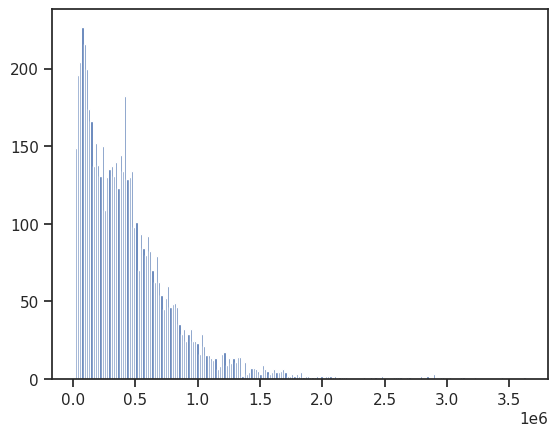

In [12]:
plt.hist(selected_loops['diff'], bins=200)

In [23]:
exploded_merged=pd.merge(loop_classes_excl,exploded,on=['chrom1','coord1','coord2'],
                        how="outer",indicator=True, suffixes=('', '_explode'))

merged_strengths = exploded_merged.merge(loop_strengths, 
                                         left_on=['chrom1','coord1','coord2'],
                                         right_on=['chr1', 'anchor1','anchor2'],
                                        suffixes=('','_ls'))

selected_loops=merged_strengths[merged_strengths['_merge']=='left_only']

selected_loops = selected_loops[selected_loops['class']=='CTCF-CTCF']
selected_loops['diff'] = selected_loops['start2']-selected_loops['start1']
selected_loops = selected_loops[selected_loops['diff'].abs()<200_000]
print(selected_loops['strength_P1'].mean())
print(selected_loops['strength_P2'].mean())
print(selected_loops['strength_P3'].mean())
        
print(selected_loops['strength_P3'].mean()/selected_loops['strength_P1'].mean())


0.12495486217621697
0.09779463216338463
0.05840282804548058
0.46739140060927187


In [24]:
selected_loops

,chrom1,start1,end1,width1,strand1,chrom2,start2,end2,width2,strand2,...,chr2,start2_ls,end2_ls,prob,strength_P1,strength_P2,strength_P3,anchor1,anchor2,diff
4,chr1,6345001.0,6350000.0,5000.0,*,chr1,6402001.0,6407000.0,5000.0,*,...,chr1,6402000,6407000,0.000000,0.282162,0.267556,0.185954,6347500.5,6404500.5,57000.0
5,chr1,6346001.0,6351000.0,5000.0,*,chr1,6436001.0,6441000.0,5000.0,*,...,chr1,6436000,6441000,0.000003,0.065417,0.064865,0.051530,6348500.5,6438500.5,90000.0
6,chr1,6346001.0,6351000.0,5000.0,*,chr1,6473001.0,6478000.0,5000.0,*,...,chr1,6473000,6478000,0.000096,-0.000335,0.014137,0.016323,6348500.5,6475500.5,127000.0
12,chr1,6792001.0,6797000.0,5000.0,*,chr1,6887001.0,6892000.0,5000.0,*,...,chr1,6887000,6892000,0.000001,0.149640,0.095896,0.054465,6794500.5,6889500.5,95000.0
20,chr1,7068001.0,7073000.0,5000.0,*,chr1,7205001.0,7210000.0,5000.0,*,...,chr1,7205000,7210000,0.000132,0.057913,0.025130,0.015593,7070500.5,7207500.5,137000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36352,chr3,172490001.0,172495000.0,5000.0,*,chr3,172665001.0,172670000.0,5000.0,*,...,chr3,172665000,172670000,NaN,NaN,0.053601,NaN,172492500.5,172667500.5,175000.0
37045,chr5,175530001.0,175535000.0,5000.0,*,chr5,175715001.0,175720000.0,5000.0,*,...,chr5,175715000,175720000,NaN,0.208499,0.115233,0.071161,175532500.5,175717500.5,185000.0
38629,chr12,44775001.0,44780000.0,5000.0,*,chr12,44930001.0,44935000.0,5000.0,*,...,chr12,44930000,44935000,NaN,NaN,NaN,NaN,44777500.5,44932500.5,155000.0
38847,chr13,31910001.0,31915000.0,5000.0,*,chr13,32000001.0,32005000.0,5000.0,*,...,chr13,32000000,32005000,NaN,0.077791,0.041170,0.022045,31912500.5,32002500.5,90000.0
